In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv("placement.csv")

In [3]:
df = df.head(100)
df.to_csv("place.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  100 non-null    float64
 1   placement_exam_marks  100 non-null    float64
 2   placed                100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df= df.rename(columns={"placement_exam_marks":"place_m"})
df.head()

,cgpa,place_m,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [6]:
import matplotlib.pyplot as plt

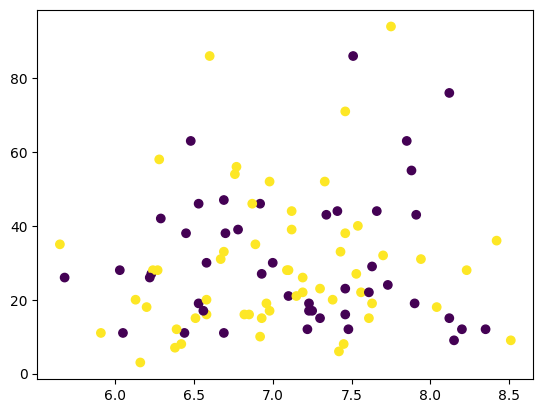

In [7]:
plt.scatter(df["cgpa"],df["place_m"],c=df["placed"])

In [8]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
x

,cgpa,place_m
0,7.19,26.0
1,7.46,38.0
2,7.54,40.0
3,6.42,8.0
4,7.23,17.0
...,...,...
95,6.89,35.0
96,7.09,28.0
97,7.33,52.0
98,8.12,76.0


In [10]:
y

0     1
1     1
2     1
3     1
4     0
     ..
95    1
96    1
97    1
98    0
99    0
Name: placed, Length: 100, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [12]:
x_train

,cgpa,place_m
2,7.54,40.0
14,7.91,43.0
44,7.88,55.0
74,6.16,3.0
34,8.15,9.0
...,...,...
6,6.69,11.0
82,7.22,12.0
12,6.58,16.0
10,6.82,16.0


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
x_train = scaler.fit_transform(x_train)
x_train

array([[ 7.08645473e-01,  6.23326042e-01],
       [ 1.27549376e+00,  7.93152511e-01],
       [ 1.22953309e+00,  1.47245839e+00],
       [-1.40554544e+00, -1.47120042e+00],
       [ 1.64317914e+00, -1.13154748e+00],
       [ 6.51960644e-02,  5.66717219e-01],
       [ 8.46527489e-01,  6.28986924e-04],
       [-1.49287072e-01,  1.30263192e+00],
       [-1.57406790e+00, -1.01832983e+00],
       [ 1.94958362e+00, -9.61721007e-01],
       [-7.92736480e-01, -6.78676891e-01],
       [-7.62096032e-01,  5.72378101e-02],
       [ 3.45556164e-02, -5.59798362e-02],
       [ 5.86083681e-01,  5.10108395e-01],
       [ 5.70763457e-01, -1.18815630e+00],
       [-8.38697152e-01,  9.62978981e-01],
       [-4.71011776e-01,  1.52906721e+00],
       [-1.31362410e+00, -1.69197483e-01],
       [-7.31455584e-01,  3.22733191e+00],
       [ 3.86920769e-01,  1.30263192e+00],
       [ 4.63521889e-01, -5.08850422e-01],
       [-2.25888192e-01, -1.12588659e-01],
       [ 6.51960644e-02,  8.49761334e-01],
       [-2.

In [16]:
x_test = scaler.transform(x_test)
x_test

array([[-0.14928707, -0.67867689],
       [ 1.18357242,  1.92532897],
       [ 1.03037018,  3.68020249],
       [-0.34844998, -0.73528571],
       [-0.11864662,  0.05723781],
       [-0.76209603, -0.50885042],
       [ 0.99972973, -0.28241513],
       [-1.34426454, -0.62206807],
       [ 0.40224099,  0.79315251],
       [-0.62421402,  0.11384663]])

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
clf= LogisticRegression()

In [19]:
# model training
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = clf.predict(x_test)

In [21]:
y_test

70    1
43    0
9     1
36    1
93    0
38    1
57    0
50    1
58    0
66    1
Name: placed, dtype: int64

In [22]:
from sklearn.metrics import accuracy_score 

In [23]:
accuracy_score(y_test,y_pred)

0.5

In [24]:
# !pip install mlxtend

In [25]:
from mlxtend.plotting import plot_decision_regions


<Axes: >

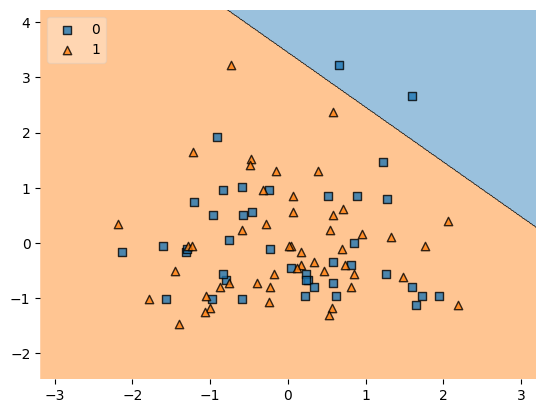

In [26]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [112]:
# !pip install pickle

In [88]:
import pickle

In [89]:
pickle.dump(clf,open('model.pkl','wb'))   # open in file 

In [27]:
df = pd.read_csv("aug_train.csv",chunksize=5000)   # dataset turns into chunks 

In [29]:
for chunks in df:
    print(chunks.shape)

(5000, 14)
(5000, 14)
(4158, 14)
